<h4> Zadanie10

In [31]:
dane = read.table("schizofrenia.txt", header = TRUE)
head(dane)

NfkB,CD28,IFN,Dikeos.manic,Dikeos.reality.distortion,Dikeos.depression,Dikeos.disorganization,Dikeos.negative,Dikeos.sum
AG,TT,TT+AA,3,19,12,42,2,78
AG,TC+CC,AT,5,29,16,46,0,96
GG,TT,AT,7,25,11,41,0,84
AG,TT,TT+AA,8,27,13,59,3,110
GG,TT,AT,3,24,13,41,2,83
GG,TT,AT,6,26,13,43,2,90


In [32]:
dim(dane)

[1] 98  9

In [33]:
summary(dane) #tutaj mamy wszystko

 NfkB       CD28       IFN      Dikeos.manic    Dikeos.reality.distortion
 AA:37   TC+CC:33   AT   :53   Min.   : 0.000   Min.   :10.00            
 AG:43   TT   :65   TT+AA:45   1st Qu.: 4.000   1st Qu.:24.00            
 GG:18                         Median : 6.000   Median :26.50            
                               Mean   : 5.847   Mean   :24.91            
                               3rd Qu.: 8.000   3rd Qu.:28.00            
                               Max.   :13.000   Max.   :31.00            
 Dikeos.depression Dikeos.disorganization Dikeos.negative   Dikeos.sum    
 Min.   : 2.00     Min.   : 2.00          Min.   :0.000   Min.   : 22.00  
 1st Qu.: 9.00     1st Qu.:26.00          1st Qu.:2.000   1st Qu.: 72.00  
 Median :12.50     Median :41.00          Median :2.000   Median : 82.50  
 Mean   :12.29     Mean   :39.19          Mean   :2.633   Mean   : 84.87  
 3rd Qu.:16.00     3rd Qu.:52.50          3rd Qu.:4.000   3rd Qu.:102.75  
 Max.   :19.00     Max.   :75.00

In [35]:
shapiro.test(Dikeos.sum, data = dane)


	Shapiro-Wilk normality test

data:  Dikeos.sum
W = 0.98347, p-value = 0.2573


In [36]:
mu = mean(dane$Dikeos.sum)
sigma = sd(dane$Dikeos.sum)
mu; sigma

[1] 84.86735

[1] 20.76855

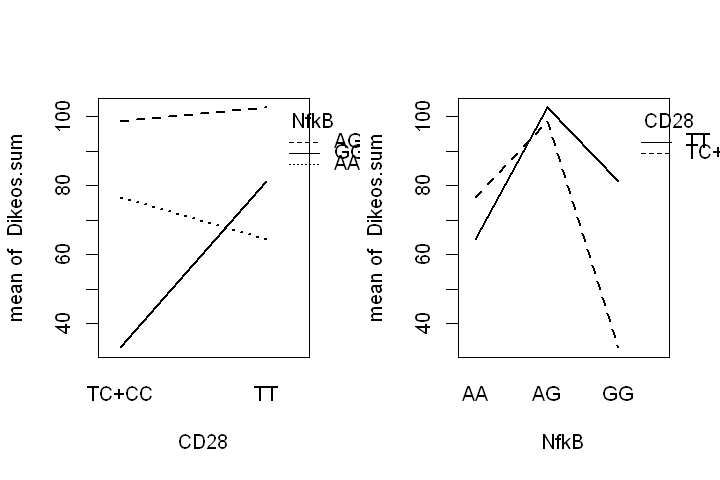

In [37]:
with(dane, interaction.plot(CD28, NfkB, Dikeos.sum, lwd = 2))
with(dane, interaction.plot(NfkB, CD28, Dikeos.sum, lwd = 2))

In [38]:
modelbezI = lm(Dikeos.sum~NfkB+CD28, data = dane)
summary(modelbezI)


Call:
lm(formula = Dikeos.sum ~ NfkB + CD28, data = dane)

Residuals:
    Min      1Q  Median      3Q     Max 
-53.581  -8.338   2.094   8.395  38.948 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  69.8265     3.0185  23.133  < 2e-16 ***
NfkBAG       31.1582     3.3578   9.279 6.26e-15 ***
NfkBGG        5.7549     4.4170   1.303    0.196    
CD28TT        0.4709     3.2860   0.143    0.886    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 14.85 on 94 degrees of freedom
Multiple R-squared:  0.5049,	Adjusted R-squared:  0.4891 
F-statistic: 31.95 on 3 and 94 DF,  p-value: 2.507e-14


In [43]:
modelzI = lm(Dikeos.sum~NfkB*CD28, data = dane)   
summary(modelzI)


Call:
lm(formula = Dikeos.sum ~ NfkB * CD28, data = dane)

Residuals:
    Min      1Q  Median      3Q     Max 
-34.552  -6.342   1.367   8.102  33.625 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)     76.706      3.101  24.735  < 2e-16 ***
NfkBAG          22.008      4.615   4.769 6.91e-06 ***
NfkBGG         -43.706      9.558  -4.573 1.50e-05 ***
CD28TT         -12.256      4.218  -2.906  0.00459 ** 
NfkBAG:CD28TT   16.093      5.925   2.716  0.00789 ** 
NfkBGG:CD28TT   60.631     10.476   5.788 9.80e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.79 on 92 degrees of freedom
Multiple R-squared:  0.6405,	Adjusted R-squared:  0.621 
F-statistic: 32.79 on 5 and 92 DF,  p-value: < 2.2e-16


In [44]:
print(anova(modelbezI, modelzI))

Analysis of Variance Table

Model 1: Dikeos.sum ~ NfkB + CD28
Model 2: Dikeos.sum ~ NfkB * CD28
  Res.Df   RSS Df Sum of Sq      F    Pr(>F)    
1     94 20715                                  
2     92 15040  2      5675 17.357 4.021e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


<h4> Zadanie12

In [2]:
dane = read.table("pekniecia.txt", header = TRUE, sep=",")
head(dane)

,probka,dawka_uM,grupa,linia,stres_oks,pekniecia_DNA
,<int>,<int>,<chr>,<chr>,<chr>,<int>
1,1,0,kontrolna,A,nie,3
2,2,0,kontrolna,A,tak,5
3,3,0,kontrolna,B,nie,4
4,4,0,kontrolna,B,tak,6
5,5,1,niska,A,nie,6
6,6,1,niska,A,tak,8


In [4]:
model =  glm(pekniecia_DNA ~ dawka_uM + linia + stres_oks, family="poisson", data=dane)
summary(model)


Call:
glm(formula = pekniecia_DNA ~ dawka_uM + linia + stres_oks, family = "poisson", 
    data = dane)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.824776   0.127426  14.320  < 2e-16 ***
dawka_uM     0.010612   0.001259   8.429  < 2e-16 ***
liniaB       0.138080   0.121651   1.135  0.25636    
stres_okstak 0.326775   0.121239   2.695  0.00703 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 92.833  on 23  degrees of freedom
Residual deviance: 21.287  on 20  degrees of freedom
AIC: 128.21

Number of Fisher Scoring iterations: 4


In [9]:
lam1 = exp(1.824776+0.010612*20+0.326775)
print(lam1)

[1] 10.63118


In [7]:
#lub
predict(model, data.frame(dawka_uM=20, linia = "A", stres_oks = "tak"), type="response", se.fit=TRUE)

$fit
       1 
10.63118 

$se.fit
       1 
1.264298 

$residual.scale
[1] 1

In [10]:
lam2 = exp(1.824776+0.010612*20.5+0.326775)
print(lam2)

[1] 10.68774


In [11]:
lam2/lam1

[1] 1.00532

In [12]:
#albo
exp(0.5*0.010612)

[1] 1.00532